<a href="https://colab.research.google.com/github/Faspeice/ml/blob/lr3/lr3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 3

# Бинарная классификация

**Цель работы**: познакомиться с применением модели машинного обучения для решения задач классификации (метод логистической регрессии)

Выполним анализ набора данных `customer_churn`. Набор представляет собой данные об активности клиентов маректинговой компании. Смысл задачи - определять, основываясь на этих данных, уйдет клиент, за которым был закрееплен менеджер, или нет. Набор данных включает следующие атрибуты:

- **Name** – имя последнего контактного лица в компании.  
- **Age** – возраст клиента.  
- **Total Purchase** – общее количество купленных объявлений.  
- **Account Manager** – двоичный код (0 – нет менеджера, 1 – назначен менеджер по работе с клиентами).  
- **Years** – всего лет в качестве клиента.  
- **Num sites** – число веб-сайтов, которые используют сервис.  
- **Onboard date** – дата, когда имя последнего контактного лица было указано в boarded.  
- **Location** – адрес штаб-квартиры клиента.  
- **Company** – название компании-клиента.  
- **Churn** – ушел или нет (целевая переменная).

 ## Импортируем библиотеки и загружаем данные

In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [78]:
url = "https://raw.githubusercontent.com/faspeice/ml/lr3/customer_churn.csv"
df = pd.read_csv(url)

# Оставляем только клиентов, которым был назначен менедер
df = df[df['Account_Manager'] == 1].copy()
df.drop(columns=['Account_Manager'], inplace = True)

df.head()

,Names,Age,Total_Purchase,Years,Num_Sites,Onboard_date,Location,Company,Churn
6,Eric Butler,44.0,11331.58,5.23,11.0,2016-12-05 03:35:43,"4846 Savannah Road West Justin, IA 87713-3460",Reynolds-Sheppard,1
7,Zachary Walsh,32.0,9885.12,6.92,9.0,2006-03-09 14:50:20,"25271 Roy Expressway Suite 147 Brownport, FM 5...",Singh-Cole,1
8,Ashlee Carr,43.0,14062.60,5.46,11.0,2011-09-29 05:47:23,"3725 Caroline Stravenue South Christineview, M...",Lopez PLC,1
9,Jennifer Lynch,40.0,8066.94,7.11,11.0,2006-03-28 15:42:45,"363 Sandra Lodge Suite 144 South Ann, WI 51655...",Reed-Martinez,1
10,Paula Harris,30.0,11575.37,5.22,8.0,2016-11-13 13:13:01,Unit 8120 Box 9160 DPO AA 43432,"Briggs, Lamb and Mathews",1


Выведем целевую переменную, целевые имена и частоту кждого уникального значения:

In [79]:
(unique,counts) = np.unique(df['Churn'], return_counts=True)
print('Unique values of the target variable:', unique)
print('Counts of the target variable:', counts)

Unique values of the target variable: [0 1]
Counts of the target variable: [349  84]


Построим столбчатую диаграмму, чтобы увидеть целевую переменную:

<Axes: xlabel='Churn', ylabel='count'>

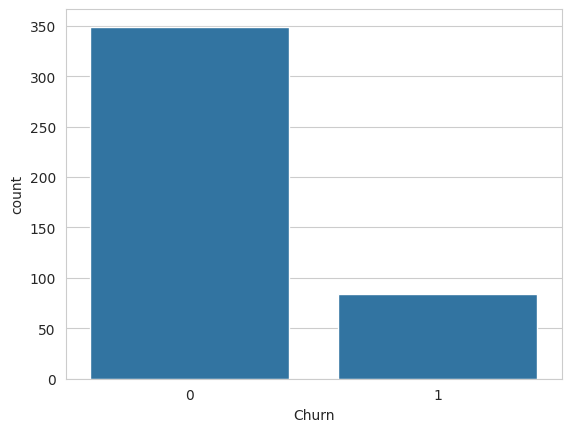

In [80]:
sns.set_style("whitegrid")
sns.countplot(df,x = 'Churn')

Анализ диаграммы показывает, что набор данных является несбалансированным

In [81]:
df.info()

print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 433 entries, 6 to 899
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Names           433 non-null    object 
 1   Age             433 non-null    float64
 2   Total_Purchase  433 non-null    float64
 3   Years           433 non-null    float64
 4   Num_Sites       433 non-null    float64
 5   Onboard_date    433 non-null    object 
 6   Location        433 non-null    object 
 7   Company         433 non-null    object 
 8   Churn           433 non-null    int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 50.0+ KB
Количество строк: 433
Количество столбцов: 9


,Age,Total_Purchase,Years,Num_Sites,Churn
count,433.000000,433.000000,433.000000,433.000000,433.000000
mean,41.722864,10102.463557,5.303487,8.648961,0.193995
std,6.077574,2429.332555,1.284794,1.756365,0.395883
min,22.000000,3263.000000,1.000000,3.000000,0.000000
25%,38.000000,8429.650000,4.520000,7.000000,0.000000
50%,41.000000,10054.600000,5.270000,9.000000,0.000000
75%,45.000000,11775.750000,6.170000,10.000000,0.000000
max,60.000000,18026.010000,8.970000,14.000000,1.000000


## Проверяем наличие пропущенных значений и выбросов

In [82]:
print(df.isnull().sum())

Names             0
Age               0
Total_Purchase    0
Years             0
Num_Sites         0
Onboard_date      0
Location          0
Company           0
Churn             0
dtype: int64


В датасете нет нулевых значений

Проверим датасет на выбросы:



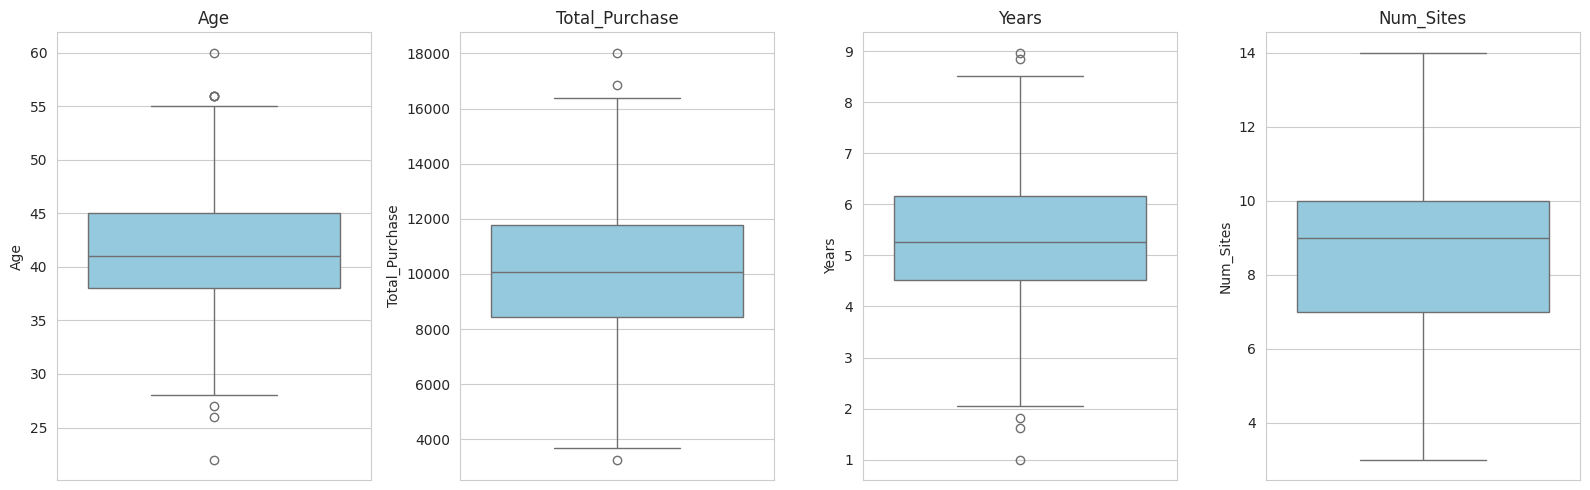

In [83]:

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
numeric_cols = ['Age', 'Total_Purchase', 'Years', 'Num_Sites']
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# Исключаем невлияющие категориальные признаки

Проверим категориальные признаки на уникальность

In [84]:
print(df['Names'].nunique())
print(df['Location'].nunique())
print(df['Company'].nunique())
print(df['Onboard_date'].nunique())

433
433
425
433


Можно сделать вывод, что категорриальные признаки Names, Location и Onboard_date не будут влиять на что либо и их можно смело удалить

In [85]:
df.drop(['Names','Location','Onboard_date'],axis = 1, inplace = True)
df.head()

,Age,Total_Purchase,Years,Num_Sites,Company,Churn
6,44.0,11331.58,5.23,11.0,Reynolds-Sheppard,1
7,32.0,9885.12,6.92,9.0,Singh-Cole,1
8,43.0,14062.60,5.46,11.0,Lopez PLC,1
9,40.0,8066.94,7.11,11.0,Reed-Martinez,1
10,30.0,11575.37,5.22,8.0,"Briggs, Lamb and Mathews",1


Преобразуем оставшиеся категориальные признаки в числовые

In [86]:
from sklearn.preprocessing import LabelEncoder
labelencoder_c = LabelEncoder()
df['Company'] = labelencoder_c.fit_transform(df['Company'])

df.head()

,Age,Total_Purchase,Years,Num_Sites,Company,Churn
6,44.0,11331.58,5.23,11.0,292,1
7,32.0,9885.12,6.92,9.0,331,1
8,43.0,14062.60,5.46,11.0,221,1
9,40.0,8066.94,7.11,11.0,287,1
10,30.0,11575.37,5.22,8.0,32,1


# Разделяем данные на признаки и целевую переменную

In [87]:
y = df['Churn']
X = df.drop('Churn', axis = 1)
X

,Age,Total_Purchase,Years,Num_Sites,Company
6,44.0,11331.58,5.23,11.0,292
7,32.0,9885.12,6.92,9.0,331
8,43.0,14062.60,5.46,11.0,221
9,40.0,8066.94,7.11,11.0,287
10,30.0,11575.37,5.22,8.0,32
...,...,...,...,...,...
892,37.0,8286.87,6.25,8.0,108
894,45.0,4863.73,5.17,8.0,65
895,42.0,12800.82,3.62,8.0,106
898,51.0,6517.93,5.47,10.0,303


# Применяем операцию нормализации для численной устойчивости

In [88]:
from sklearn.preprocessing import StandardScaler
standardizer = StandardScaler()
X = standardizer.fit_transform(X)
X

array([[ 0.37511189,  0.50653345, -0.05726388,  1.34013045,  0.64183762],
       [-1.60164408, -0.08956986,  1.25964335,  0.20009806,  0.95608517],
       [ 0.21038223,  1.63201916,  0.12196018,  1.34013045,  0.06974595],
       ...,
       [ 0.04565256,  1.11202467, -1.3118323 , -0.36991813, -0.85688142],
       [ 1.52821954, -1.47722876,  0.12975253,  0.77011426,  0.73047155],
       [-0.44853643, -0.3242758 , -0.22090324,  0.77011426, -1.00997638]])

# Разделяем данные на тренировочный и тестовые наборы

80% данных используется для обучения и 20% для тестирования

In [89]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

# Обучаем модель логистической регрессии

In [90]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

# Делаем прогноз на основе данных тестировани

In [91]:
y_pred = model.predict(X_test)

# Рассчитываем показатели точности, сравнив фактичнеские и прогнозируемые значения

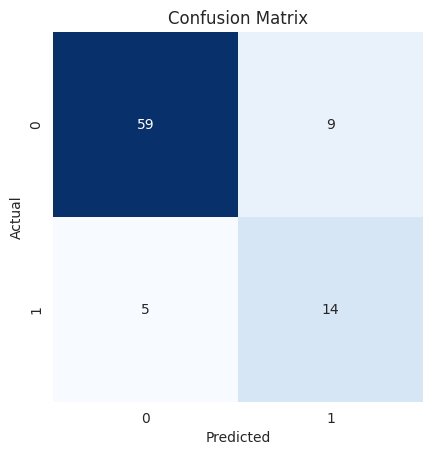

In [92]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [93]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.2f}")

Точность: 0.84


In [94]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Точность: {precision:.2f}")
print(f"Полнота: {recall:.2f}")

Точность: 0.61
Полнота: 0.74


In [95]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1-мера: {f1:.2f}")

F1-мера: 0.67


In [96]:
df.corr()

,Age,Total_Purchase,Years,Num_Sites,Company,Churn
Age,1.000000,-0.060500,-0.000146,0.005611,-0.052832,0.024321
Total_Purchase,-0.060500,1.000000,-0.041020,-0.022965,0.081958,0.036453
Years,-0.000146,-0.041020,1.000000,0.061939,0.018187,0.200007
Num_Sites,0.005611,-0.022965,0.061939,1.000000,-0.039350,0.574238
Company,-0.052832,0.081958,0.018187,-0.039350,1.000000,-0.031432
Churn,0.024321,0.036453,0.200007,0.574238,-0.031432,1.000000


# Строим ROC-кривую

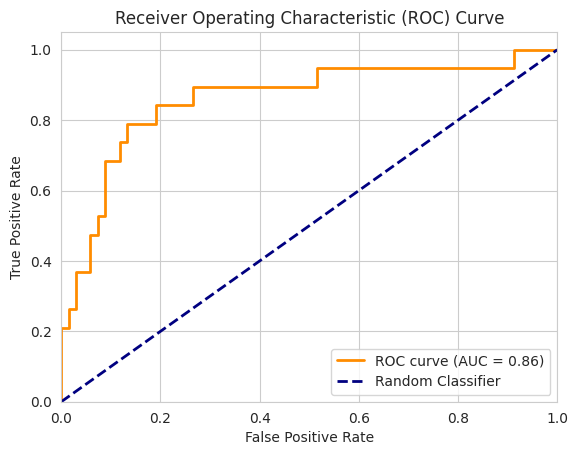

In [97]:
from sklearn.metrics import roc_curve, auc

y_score = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()